In [7]:
# 수집한 데이터를 사용하기 전, 확인하고 점검하기 위한 코드

# 주요 4개 라이브러리 import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 준비
df = pd.read_csv('dataset/Occupancy_Estimation.csv')

# 결측치 수량 체크
print(df.isnull().sum())

# 결측치가 없으므로 dropna() 미사용

Date                    0
Time                    0
S1_Temp                 0
S2_Temp                 0
S3_Temp                 0
S4_Temp                 0
S1_Light                0
S2_Light                0
S3_Light                0
S4_Light                0
S1_Sound                0
S2_Sound                0
S3_Sound                0
S4_Sound                0
S5_CO2                  0
S5_CO2_Slope            0
S6_PIR                  0
S7_PIR                  0
Room_Occupancy_Count    0
dtype: int64


In [8]:
# 중복 데이터 체크
print(df.duplicated().sum())

# 중복 데이터가 없으므로 drop_duplicates() 미사용

0


In [9]:
# 분산이 0인 피쳐 체크
numeric_df = df.select_dtypes(include=[np.number])
variances = numeric_df.var()
zero_var_features = variances[variances == 0].index.tolist()
print(zero_var_features)

# 분산이 0인 피쳐가 없으므로 drop(feature=zero_var_features) 미사용
# 문자형 범주가 없으므로 OneHotEncoding 미사용

[]


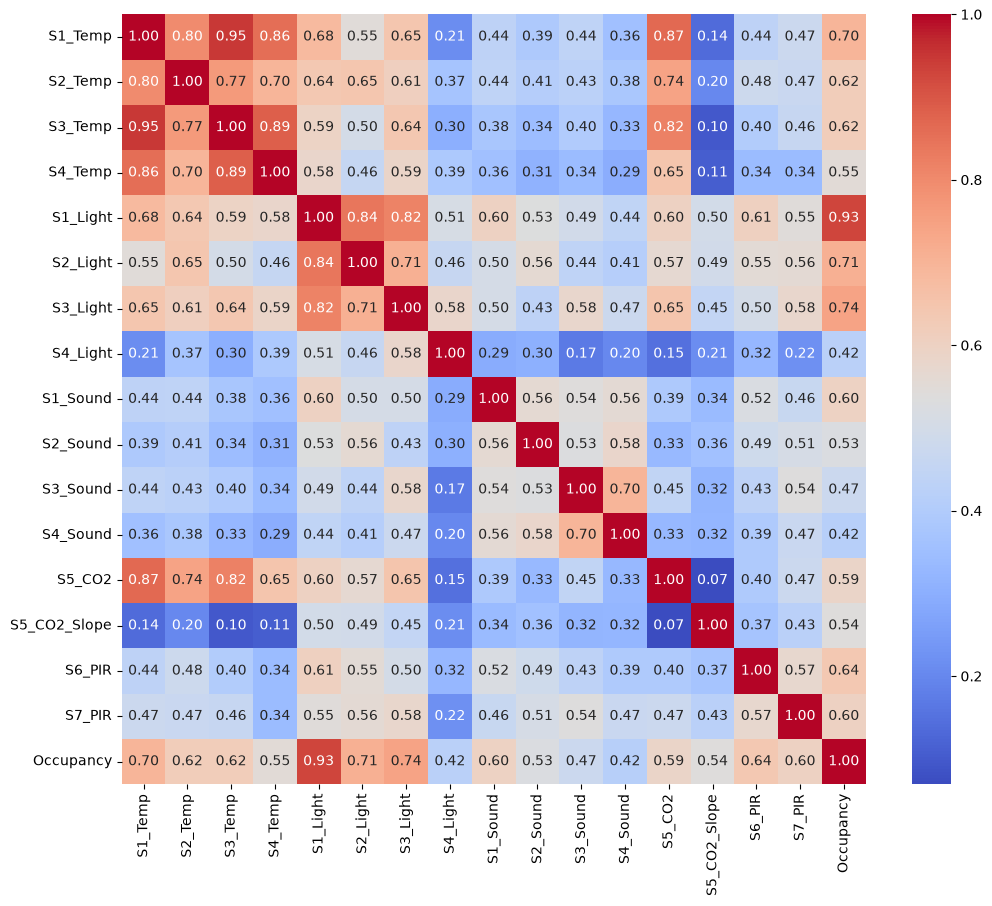

In [10]:
# 데이터 확인 결과 사람이 몇명 있는지 나타내는 Room_Occupancy_count 존재
# 해당 컬럼을 타겟으로 설정하고, 이진 분류 꼴로 변경
df['Occupancy'] = (df['Room_Occupancy_Count'] > 0).astype(int)

# 필요 없는 컬럼 삭제
# 날짜, 시간, 원본 종속변수 삭제
df_for_heatmap = df.drop(columns=['Date', 'Time', 'Room_Occupancy_Count'])

# 독립변수 선택을 위한 상관계수 히트맵 시각화
# 히트맵 수치 표시, 소수점 이하 2자리 표시
plt.figure(figsize=(12, 10))
sns.heatmap(df_for_heatmap.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

         feature           VIF
0        S1_Temp  64687.073309
1        S2_Temp   7666.602587
2        S3_Temp  54658.918326
3        S4_Temp  33238.953387
4       S1_Light      8.910283
5       S2_Light      5.294959
6       S3_Light      8.389188
7       S4_Light      4.367700
8       S1_Sound      2.673392
9       S2_Sound      2.609162
10      S3_Sound      3.036633
11      S4_Sound      4.070381
12        S5_CO2     26.260452
13  S5_CO2_Slope      1.932097
14        S6_PIR      2.177863
15        S7_PIR      2.404979


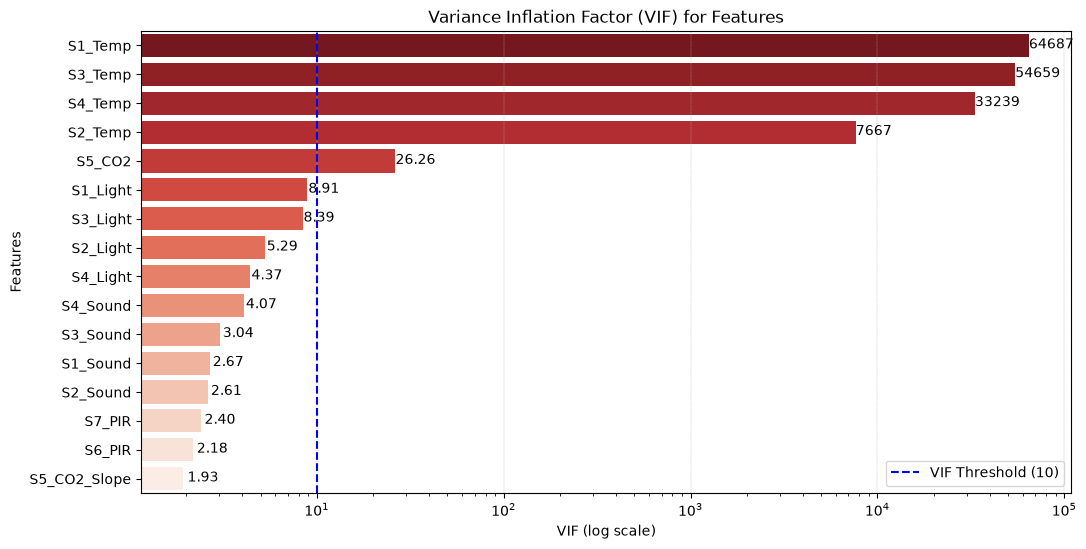

In [25]:
# VIF 계산을 위한 라이브러리 import
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF 계산을 위한 독립변수 추출
X_features = df_for_heatmap.drop(columns=['Occupancy'])

# 데이터프레임 생성
vif_df = pd.DataFrame()
vif_df['feature'] = X_features.columns
vif_df['VIF'] = [variance_inflation_factor(X_features.values, i) for i in range(X_features.shape[1])]

# 시각화 전 텍스트 값 원본 출력
print(vif_df)

# VIF 결과 시각화
vif_df = vif_df.sort_values(by='VIF', ascending=False).reset_index(drop=True)
plt.figure(figsize=(12, 6))

# VIF 막대 그래프 생성
ax = sns.barplot(x='VIF', y='feature', data=vif_df, palette='Reds_r', hue='feature', legend=False)

# 다중공선성 임계치(10) 가로선 표시
plt.axvline(x=10, color='blue', linestyle='--', label='VIF Threshold (10)')

# 값이 너무 커서 그래프가 깨지는 것을 방지하기 위한 로그스케일 적용
plt.xscale('log')

# 그래프 제목 및 레이블 설정
# 그리드 선은 세로선만 렌더링
# 그래프에 실제 값 표시, 실제 값이 100을 초과하는 경우에는 소수점 아래 자리를 표시하지 않음
for i in ax.patches:
    if i.get_width() > 100:
        ax.text(i.get_width() + 0.1, i.get_y() + 0.5, f'{i.get_width():.0f}', fontsize=10, color='black')
    else:
        ax.text(i.get_width() + 0.1, i.get_y() + 0.5, f'{i.get_width():.2f}', fontsize=10, color='black')
plt.grid(axis='x', linestyle='--', linewidth=0.3)
plt.title('Variance Inflation Factor (VIF) for Features')
plt.xlabel('VIF (log scale)')
plt.ylabel('Features')
plt.legend(loc='lower right')

plt.show()

In [12]:
# 모델 비교 및 선정을 위해 주요 모델과 평가 지표 import
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 분류 모델 import
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neighbors import KNeighborsClassifier

# 데이터 분할
# 독립변수 및 종속변수 설정
X = df_for_heatmap.drop(columns=['Occupancy'])
y = df_for_heatmap['Occupancy']

# 테스트 데이터 20% 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 비교할 분류 모델 정의
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Support Vector Machine': CalibratedClassifierCV(SVC(random_state=42)),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

# 모델 학습, 예측, 성능 평가(반복문)
results = {}

for name, model in models.items():
    # 모델 학습
    model.fit(X_train, y_train)
    
    # 예측값 및 예측 확률 계산
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    # 성능 평가 지표 계산
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None
    
    # 결과 저장
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC AUC': roc_auc
    }
    
    print(f"{name} - Acc: {accuracy:.4f}, F1: {f1:.4f}, AUC: {roc_auc:.4f}" if roc_auc is not None else f"{name} - Acc: {accuracy:.4f}, F1: {f1:.4f}")

# 결과를 데이터프레임으로 변환
results_df = pd.DataFrame(results).T.sort_values(by='F1 Score', ascending=False)
print("\nModel Performance Comparison:")
print(results_df)

Logistic Regression - Acc: 0.9956, F1: 0.9889, AUC: 0.9999
Decision Tree - Acc: 0.9985, F1: 0.9963, AUC: 0.9963
Random Forest - Acc: 1.0000, F1: 1.0000, AUC: 1.0000
Gradient Boosting - Acc: 0.9980, F1: 0.9951, AUC: 1.0000
Support Vector Machine - Acc: 0.9832, F1: 0.9564, AUC: 0.9701
K-Nearest Neighbors - Acc: 1.0000, F1: 1.0000, AUC: 1.0000

Model Performance Comparison:
                        Accuracy  Precision    Recall  F1 Score   ROC AUC
K-Nearest Neighbors     1.000000   1.000000  1.000000  1.000000  1.000000
Random Forest           1.000000   1.000000  1.000000  1.000000  1.000000
Decision Tree           0.998519   1.000000  0.992629  0.996301  0.996314
Gradient Boosting       0.998026   1.000000  0.990172  0.995062  0.999967
Logistic Regression     0.995558   0.990148  0.987715  0.988930  0.999859
Support Vector Machine  0.983218   1.000000  0.916462  0.956410  0.970124


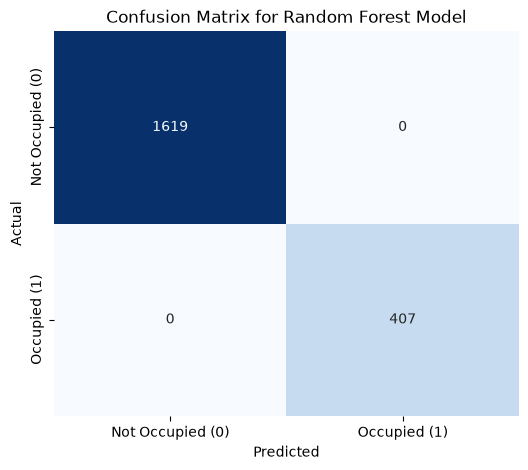

In [13]:
# Random Forest 모델의 예측 결과를 혼동 행렬로 시각화
# 시각화를 위한 라이브러리 import
from sklearn.metrics import confusion_matrix

# Random Forest 모델 단독 학습 및 예측
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# 혼동 행렬 계산
cm_all = confusion_matrix(y_test, y_pred_rf)

# 히트맵 시각화
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_all, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=False,
    xticklabels=['Not Occupied (0)', 'Occupied (1)'],
    yticklabels=['Not Occupied (0)', 'Occupied (1)']
)
plt.title('Confusion Matrix for Random Forest Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [14]:
# 제거할 다중공선성 피쳐 정의
# S2~4_Temp, S2_Light, S3_Light 대상
drop_features = ['S2_Temp', 'S3_Temp', 'S4_Temp', 'S2_Light', 'S3_Light']

# 모든 피쳐를 남긴 데이터프레임 선언
# Feature Importance 비교용
df_all = df.drop(columns=['Date', 'Time', 'Room_Occupancy_Count'])

# 다중공선성을 제거한 주 데이터셋
df_selected = df_all.drop(columns=drop_features)

# 형태 확인
print("df_all shape:", df_all.shape)
print("df_selected shape:", df_selected.shape)

df_all shape: (10129, 17)
df_selected shape: (10129, 12)


In [15]:
# Random Forest 모델 정의

# 모델 정의에 필요한 라이브러리 import
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split

# 원본

# 독립변수와 종속변수 정의
X = df_selected.drop(columns=['Occupancy'])
y = df_selected['Occupancy']

# 테스트 데이터 20% 분리
# 종속변수의 비율을 유지하기 위해 stratify=y 사용
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 하이퍼파라미터 그리드 정의
# S1_Light 피쳐가 상당히 강력해서, 제약이 없으면 모든 트리가 S1_Light 피쳐를 선택하게 됨
# 트리의 다양성을 위해 max_features를 제한함
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# GridSearchCV를 사용하여 최적의 하이퍼파라미터 탐색
# 종속변수의 비율이 불균형하므로 F1 score를 평가 지표로 사용
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, scoring='f1')

# 학습 진행
grid_search.fit(X_train, y_train)

# 최적의 하이퍼파라미터 출력
print("최적의 하이퍼파라미터: ", grid_search.best_params_)
print("최고의 F1 score: ", grid_search.best_score_)

# 최적의 모델 저장
best_rf = grid_search.best_estimator_

최적의 하이퍼파라미터:  {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
최고의 F1 score:  0.9990147730209319


In [16]:
# 성능 지표 계산을 위한 라이브러리 import
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

# 최적 모델로 예측 실행
y_pred = best_rf.predict(X_test)

# 주요 성능 지표 계산
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== [최적 모델 성능 평가 결과] ===")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")
print("\n[상세 분류 보고서]")
print(classification_report(y_test, y_pred))

=== [최적 모델 성능 평가 결과] ===
Accuracy  : 0.9995
Precision : 1.0000
Recall    : 0.9974
F1-Score  : 0.9987

[상세 분류 보고서]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1646
           1       1.00      1.00      1.00       380

    accuracy                           1.00      2026
   macro avg       1.00      1.00      1.00      2026
weighted avg       1.00      1.00      1.00      2026



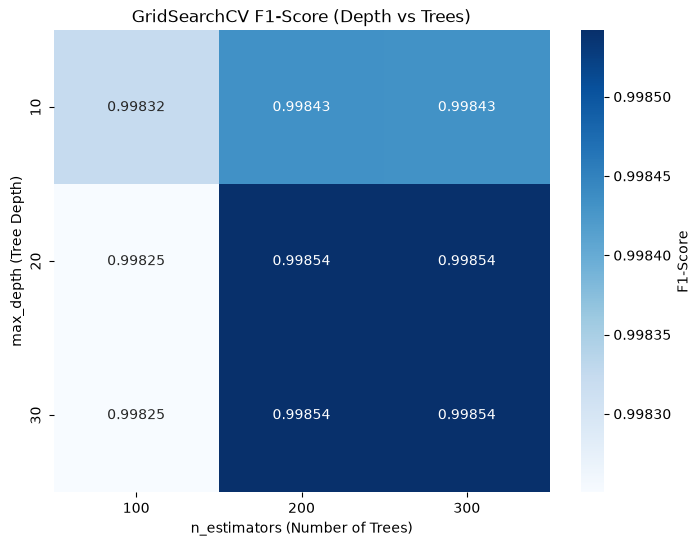

In [17]:
# 모델 학습 평가 시각화
cv_results = pd.DataFrame(grid_search.cv_results_)

# pivot table 생성
pivot_df = cv_results.pivot_table(
    index='param_max_depth', 
    columns='param_n_estimators', 
    values='mean_test_score'
)
pivot_df.index = [str(x) if x is not None else 'None' for x in pivot_df.index]

# 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_df, annot=True, fmt=".5f", cmap='Blues', cbar_kws={'label': 'F1-Score'})
plt.title('GridSearchCV F1-Score (Depth vs Trees)')
plt.xlabel('n_estimators (Number of Trees)')
plt.ylabel('max_depth (Tree Depth)')
plt.show()

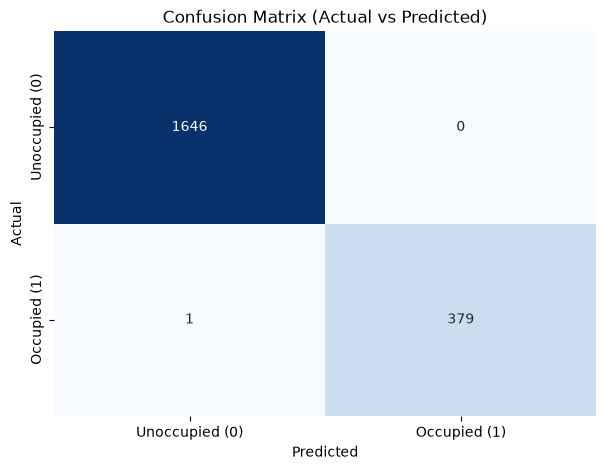

=== [상세 분류 보고서] ===
                precision    recall  f1-score   support

Unoccupied (0)       1.00      1.00      1.00      1646
  Occupied (1)       1.00      1.00      1.00       380

      accuracy                           1.00      2026
     macro avg       1.00      1.00      1.00      2026
  weighted avg       1.00      1.00      1.00      2026



In [18]:
# 예측값 대 실제값 평가 시각화

# 혼동 행렬 시각화
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    cbar=False,
    xticklabels=['Unoccupied (0)', 'Occupied (1)'],
    yticklabels=['Unoccupied (0)', 'Occupied (1)']
)
plt.title('Confusion Matrix (Actual vs Predicted)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 상세 성능 리포트 출력
print("=== [상세 분류 보고서] ===")
print(classification_report(y_test, y_pred, target_names=['Unoccupied (0)', 'Occupied (1)']))

=== [Feature Importance (All Features)] ===
         Feature  Importance
4       S1_Light    0.256869
8       S1_Sound    0.172363
5       S2_Light    0.162404
13  S5_CO2_Slope    0.139911
9       S2_Sound    0.085054
10      S3_Sound    0.076946
6       S3_Light    0.030472
1        S2_Temp    0.020357
12        S5_CO2    0.011538
7       S4_Light    0.011273
15        S7_PIR    0.007363
2        S3_Temp    0.007223
3        S4_Temp    0.006193
0        S1_Temp    0.005863
14        S6_PIR    0.003903
11      S4_Sound    0.002267

=== [Feature Importance (Selected Features)] ===
         Feature  Importance
1       S1_Light    0.301810
3       S1_Sound    0.236857
8   S5_CO2_Slope    0.179577
4       S2_Sound    0.083843
5       S3_Sound    0.066079
0        S1_Temp    0.039932
6       S4_Sound    0.025114
9         S6_PIR    0.021670
2       S4_Light    0.019507
7         S5_CO2    0.017213
10        S7_PIR    0.008398


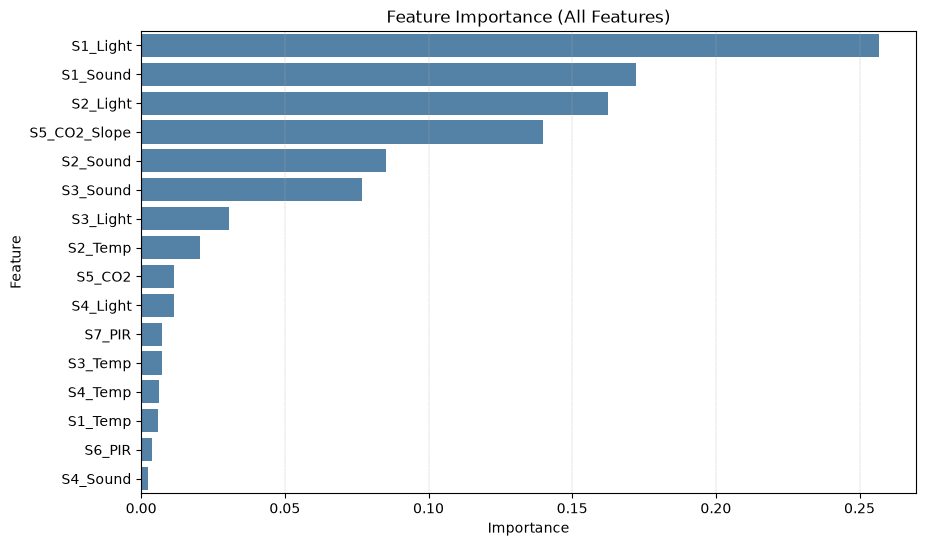

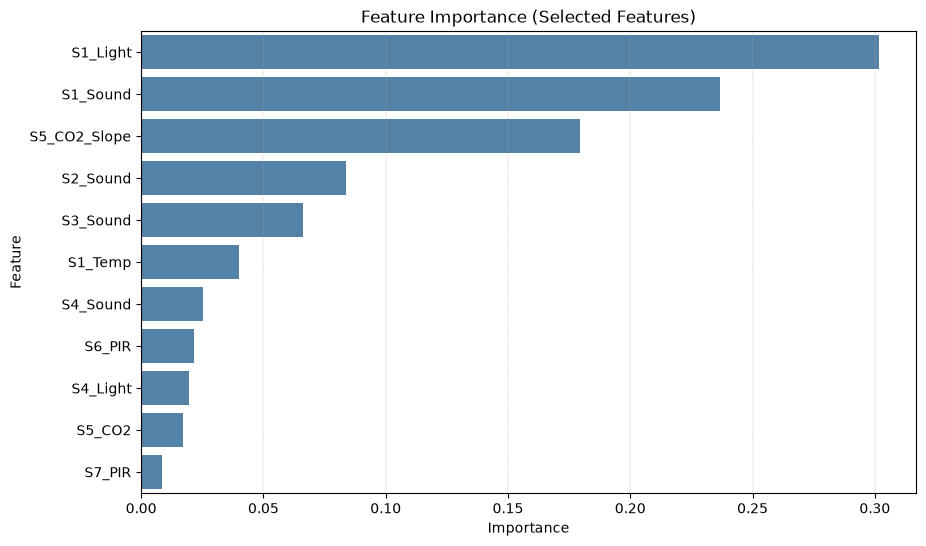

In [31]:
# Feature Importance 시각화

# Feature Importance 비교를 위해 모든 피처로 모델 학습 진행
# EDA로 피처를 선정한 모델은 best_rf로 이미 존재함

# 독립변수와 종속변수 정의(모든 피처 사용)
X_all = df_all.drop(columns=['Occupancy'])
y_all = df_all['Occupancy']

# 모든 피처로 학습한 Random Forest 모델 정의 및 학습
# 해당 모델은 예측을 수행하지 않고, Feature Importance 계산용으로만 사용
# 데이터 분할 없음
rf_all = RandomForestClassifier(random_state=42, **grid_search.best_params_)
rf_all.fit(X_all, y_all)

# rf_all에 대한 Feature Importance 계산
fi_all = pd.DataFrame({
    'Feature': X_all.columns,
    'Importance': rf_all.feature_importances_
}).sort_values(by='Importance', ascending=False)

# best_rf에 대한 Feature Importance 계산
fi_selected = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 두 모델의 Feature Importance 원본 값을 출력
print("=== [Feature Importance (All Features)] ===")
print(fi_all)
print("\n=== [Feature Importance (Selected Features)] ===")
print(fi_selected)

# rf_all에 대한 Feature Importance 시각화
# 그리드는 세로선만 렌더링
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_all, color='steelblue')
plt.title('Feature Importance (All Features)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', linewidth=0.3)
plt.show()

#  best_rf에 대한 Feature Importance 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_selected, color='steelblue')
plt.title('Feature Importance (Selected Features)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', linewidth=0.3)
plt.show()

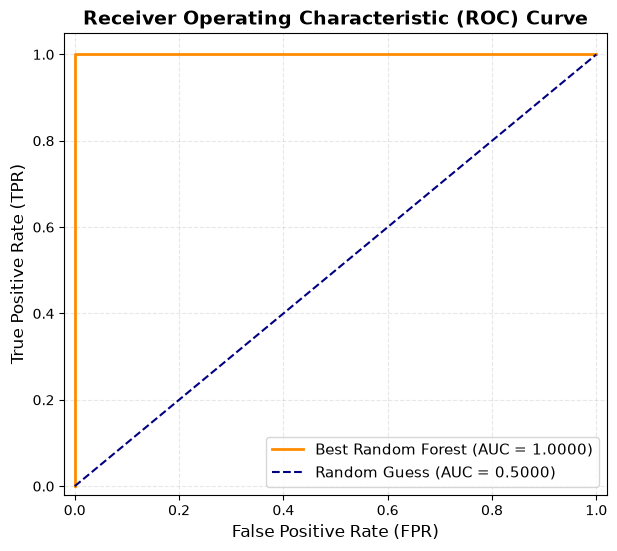

In [20]:
# ROC 시각화
# ROC Curve 시각화를 위해 필요한 라이브러리 import
from sklearn.metrics import roc_curve, roc_auc_score

# best_rf가 학습할 때 사용한 feature 이름 목록 가져오기
feature_names = best_rf.feature_names_in_

# X_test의 컬럼을 best_rf 학습 기준과 완벽히 동기화
X_test_scaled = X_test[feature_names]

# 확률 예측 재시도
y_proba_rf = best_rf.predict_proba(X_test_scaled)[:, 1]

# ROC Curve 계산 및 시각화 진행
fpr, tpr, thresholds = roc_curve(y_test, y_proba_rf)
auc_score = roc_auc_score(y_test, y_proba_rf)

# ROC Curve 시각화
plt.figure(figsize=(7, 6))

# best_rf ROC 곡선 Plot
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Best Random Forest (AUC = {auc_score:.4f})')

# 기준선 (Random Classifier Line)
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Guess (AUC = 0.5000)')

# 스타일 설정
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

In [21]:
import os
import joblib

# 1. 모델 저장 디렉토리 생성
os.makedirs('model', exist_ok=True)

# 2. 최적화된 랜덤포레스트 모델 저장
joblib.dump(best_rf, 'model/best_rf_model.joblib')

# 3. 모델이 학습한 피처 이름 및 순서 정보 저장
# X_train (또는 best_rf.feature_names_in_)에서 컬럼 리스트 추출
feature_meta = {
    'feature_names': list(X_train.columns)
}
joblib.dump(feature_meta, 'model/features_meta.joblib')

print("모델 및 피처 메타데이터 저장 완료!")

모델 및 피처 메타데이터 저장 완료!
